Dataset shape: (1000, 20)
Class balance:
 class
1    700
0    300
Name: count, dtype: int64 

===== Logistic Regression =====
              precision    recall  f1-score   support

         Bad       0.54      0.47      0.50        60
        Good       0.78      0.83      0.81       140

    accuracy                           0.72       200
   macro avg       0.66      0.65      0.65       200
weighted avg       0.71      0.72      0.71       200

===== Decision Tree =====
              precision    recall  f1-score   support

         Bad       0.45      0.37      0.40        60
        Good       0.75      0.81      0.78       140

    accuracy                           0.68       200
   macro avg       0.60      0.59      0.59       200
weighted avg       0.66      0.68      0.66       200

===== Random Forest =====
              precision    recall  f1-score   support

         Bad       0.68      0.42      0.52        60
        Good       0.79      0.91      0.84       140

    

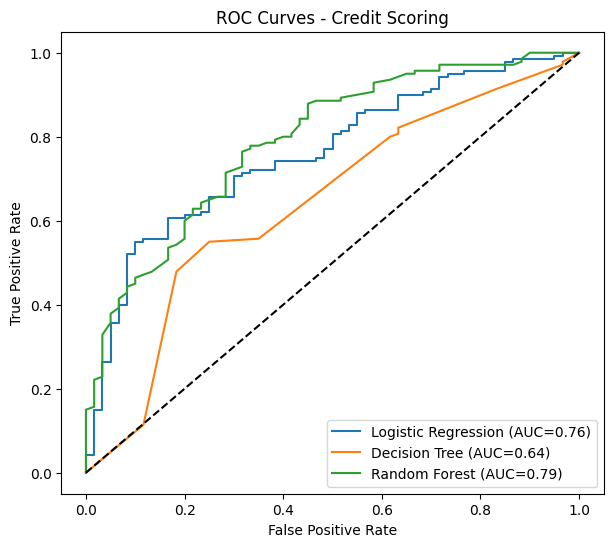


=== Model Comparison ===
              Model  Precision  Recall  F1-Score  ROC-AUC
Logistic Regression      0.784   0.829     0.806    0.760
      Decision Tree      0.748   0.807     0.777    0.643
      Random Forest      0.785   0.914     0.845    0.790


In [1]:
# CodeAlpha_CreditScoringModel
# Task 1: Credit Scoring Model
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (precision_score, recall_score, f1_score,
                             roc_auc_score, roc_curve, classification_report)


data = fetch_openml("credit-g", version=1, as_frame=True)
X = data.data.copy()
y = (data.target == "good").astype(int)
print("Dataset shape:", X.shape)
print("Class balance:\n", y.value_counts(), "\n")


X["credit_per_month"] = X["credit_amount"] / X["duration"]
X["credit_to_age"] = X["credit_amount"] / X["age"]
X["installment_burden"] = X["installment_commitment"] * X["credit_per_month"]

num_cols = X.select_dtypes(include=["number"]).columns.tolist()
cat_cols = X.select_dtypes(exclude=["number"]).columns.tolist()

pre = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
])


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)


models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=42),
}

results = []
plt.figure(figsize=(7, 6))
for name, clf in models.items():
    pipe = Pipeline([("pre", pre), ("clf", clf)])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    prob = pipe.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1-Score": f1_score(y_test, pred),
        "ROC-AUC": roc_auc_score(y_test, prob),
    })
    print(f"===== {name} =====")
    print(classification_report(y_test, pred, target_names=["Bad", "Good"]))

    fpr, tpr, _ = roc_curve(y_test, prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test, prob):.2f})")

plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - Credit Scoring")
plt.legend()
plt.savefig("roc_curves.png", dpi=150)
plt.show()

print("\n=== Model Comparison ===")
print(pd.DataFrame(results).round(3).to_string(index=False))
